# Neural network regression on concrete strength data

In a previous notebook, we used **multivariate linear regression** to predict the compressive strength of concrete from its mix design.

In this notebook, we will solve the same regression problem using a simple neural network implemented with **PyTorch**.

In [122]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

import torch
import torch.nn as nn
import torch.optim as optim

### Utility function: parity plot

In [123]:
def parity_plot(y_true, y_pred, title="Parity Plot"):
    plt.figure()
    
    # Scatter plot: true vs predicted
    #plt.scatter(y_true, y_pred, s=80, c='k', marker='x', linewidth=0.7, zorder=1)

    # For large datasets, individual scatter points may overlap, making it difficult to assess the distribution of predictions. 
    # Hexagonal binning addresses this issue by grouping points into bins and visualizing their frequency through color intensity. 
    # The associated colorbar indicates the number of samples within each bin.
    hb = plt.hexbin(y_true, y_pred, zorder=-1, cmap='gray_r', mincnt=1, gridsize=12, edgecolors='none')
    cb = plt.colorbar(hb)
    cb.set_label("Counts per bin")
    
    # Ideal line (perfect prediction)
    min_val = min(np.min(y_true), np.min(y_pred))
    max_val = max(np.max(y_true), np.max(y_pred))
    plt.plot([min_val, max_val], [min_val, max_val], 'goldenrod', linewidth=1.5, zorder=1, linestyle='--')

    plt.xlim([min_val, max_val])
    plt.ylim([min_val, max_val])
    plt.xlabel("True strength [MPa]")
    plt.ylabel("Predicted strength [MPa]")
    plt.title(title)

    # Mean squarred error
    mse = np.mean((y_true - y_pred)**2)
    # R^2 score (coefficient of determination)
    r2 = 1 - np.sum((y_true - y_pred)**2) / np.sum((y_true - np.mean(y_true))**2)
    
    plt.text(min_val, max_val, f"MSE = {mse:.3f}\nR² = {r2:.3f}",
             verticalalignment='top')
    
    plt.show()

### Load data

The dataset contains:

- Input variables describing the concrete composition
- One target variable corresponding to the concrete compressive strength

In [124]:
# Load data from Excel
file_path = "../Data/Concrete/Concrete.xls"
df = pd.read_excel(file_path)

# Display first rows
df.head()

# The dataset is stored in Excel format (.xls).
# Pandas requires the 'xlrd' package to read this format.
# If you get an error, install it via: pip install xlrd.

,Cement (component 1)(kg in a m^3 mixture),Blast Furnace Slag (component 2)(kg in a m^3 mixture),Fly Ash (component 3)(kg in a m^3 mixture),Water (component 4)(kg in a m^3 mixture),Superplasticizer (component 5)(kg in a m^3 mixture),Coarse Aggregate (component 6)(kg in a m^3 mixture),Fine Aggregate (component 7)(kg in a m^3 mixture),Age (day),"Concrete compressive strength(MPa, megapascals)"
0,540.0,0.0,0.0,162.0,2.5,1040.0,676.0,28,79.986111
1,540.0,0.0,0.0,162.0,2.5,1055.0,676.0,28,61.887366
2,332.5,142.5,0.0,228.0,0.0,932.0,594.0,270,40.269535
3,332.5,142.5,0.0,228.0,0.0,932.0,594.0,365,41.052780
4,198.6,132.4,0.0,192.0,0.0,978.4,825.5,360,44.296075


### Define inputs and outputs

In [125]:
# In this dataset, the last column is the concrete compressive strength target
X = df.iloc[1:, :-1].values # all columns except last → input features
y = df.iloc[1:, -1].values.reshape(-1, 1) # last column → target

N, d = X.shape

print("Input shape:", X.shape)
print("Target shape:", y.shape)
print(f"Number of samples: {N}")
print(f"Number of input features: {d}")

Input shape: (1029, 8)
Target shape: (1029, 1)
Number of samples: 1029
Number of input features: 8


### Data normalization

Neural networks are very sensitive to the scale of the input variables. Without normalization:

- Optimization becomes unstable
- Gradients can become too large or too small
- Training becomes less effective

We standardize the features to display zero mean and unit variance.


---

### Split and normalize the data

- Split using 80% train and 20% test
- Compute normalization statistics from training data
- Consistently apply normalization to the test data


In [126]:
# Split data (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=4)

# Standardization
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

## Example: linear regression with PyTorch

Let us first regenerate the data and the training loop

In [127]:
t_c = torch.tensor([0.5,  14.0, 15.0, 28.0, 11.0,  8.0,  3.0, -4.0,  6.0, 13.0, 21.0]).unsqueeze(1) 
t_u = torch.tensor([35.7, 55.9, 58.2, 81.9, 56.3, 48.9, 33.9, 21.8, 48.4, 60.4, 68.4]).unsqueeze(1) 
n_samples = t_u.shape[0]
n_val = int(0.2 * n_samples)
shuffled_indices = torch.randperm(n_samples)
train_indices = shuffled_indices[:-n_val]
val_indices = shuffled_indices[-n_val:]
t_un_train = 0.1*t_u[train_indices]
t_c_train = t_c[train_indices]
t_un_val = 0.1*t_u[val_indices]
t_c_val = t_c[val_indices]


def training_loop(n_epochs, optimizer, model, loss_fn, t_u_train, t_u_val,
                  t_c_train, t_c_val):
    for epoch in range(1, n_epochs + 1):
        t_p_train = model(t_u_train) 
        loss_train = loss_fn(t_p_train, t_c_train)

        t_p_val = model(t_u_val) 
        loss_val = loss_fn(t_p_val, t_c_val)
        
        optimizer.zero_grad()
        loss_train.backward() 
        optimizer.step()

        if epoch == 1 or epoch % 1000 == 0:
            print(f"Epoch {epoch}, Training loss {loss_train.item():.4f},"
                  f" Validation loss {loss_val.item():.4f}")

Earlier, it was our responsibility to create parameters and pass them as the first argument
to ``optim.SGD``. Now we can use the ``parameters`` method to ask any ``nn.Module`` for
a list of parameters owned by it or any of its submodules. In our case
``linear_model.parameters()``

There’s one last bit that we can leverage from torch.nn: the loss. Indeed, nn comes
with several common loss functions, among them ``nn.MSELoss`` (MSE stands for Mean
Square Error), which is exactly what we defined earlier as our ``loss_fn``. Loss functions
in nn are still subclasses of ``nn.Module``

In [128]:
import torch.optim as optim

training_loop(
    n_epochs = 3000, 
    optimizer = optim.SGD(linear_model.parameters(),lr=1e-2),
    model = linear_model,
    loss_fn = nn.MSELoss(), # <1>
    t_u_train = t_un_train,
    t_u_val = t_un_val, 
    t_c_train = t_c_train,
    t_c_val = t_c_val)

print()
print(linear_model.weight)
print(linear_model.bias)

NameError: name 'linear_model' is not defined

Everything else input into our training loop stays the same. Even our results remain
the same as before. Of course, getting the same results is expected, as a difference
would imply a bug in one of the two implementations.

### Convert NumPy arrays to PyTorch tensors

In [129]:
X_train_tensor = torch.tensor(X_train_scaled, dtype=torch.float32)
X_test_tensor = torch.tensor(X_test_scaled, dtype=torch.float32)

y_train_tensor = torch.tensor(y_train, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test, dtype=torch.float32)

### Define the neural network

We use a small feed-forward neural network:

- Input layer
- One hidden layer with ReLU activation
- One output neuron for regression

Mathematically:

$\hat{y} = \mathbf{W}_2 \cdot \sigma(\mathbf{W}_1 \cdot \mathbf{x} + \mathbf{b}_1) + \mathbf{b}_2$

where:

- $\sigma$ is the ReLU activation function
- $\mathbf{W}$ and $\mathbf{b}$ are trainable parameters

In [130]:
class ConcreteNN(nn.Module):

    def __init__(self, input_size):
        super().__init__()

        self.network = nn.Sequential(
            nn.Linear(input_size, 16),
            nn.ReLU(),
            nn.Linear(16, 1)
        )

    def forward(self, x):
        return self.network(x)

In [131]:
input_size = X_train_tensor.shape[1]

model = ConcreteNN(input_size)

print(model)

ConcreteNN(
  (network): Sequential(
    (0): Linear(in_features=8, out_features=16, bias=True)
    (1): ReLU()
    (2): Linear(in_features=16, out_features=1, bias=True)
  )
)


### Training loop

We minimize the **Mean Squared Error (MSE)** loss function
    
$MSE = \frac{1}{N} \sum_i (y_i - \hat{y}_i)^2$,

using the **Adam optimizer**

In [132]:
def training_loop(n_epochs, optimizer, model, loss_fn, t_u_train, t_u_val,
                  t_c_train, t_c_val):

    loss_history = []
    
    for epoch in range(1, n_epochs + 1):
        t_p_train = model(t_u_train) 
        loss_train = loss_fn(t_p_train, t_c_train)

        t_p_val = model(t_u_val) 
        loss_val = loss_fn(t_p_val, t_c_val)
        
        optimizer.zero_grad()
        loss_train.backward() 
        optimizer.step()

        loss_history.append([loss_train.item(),loss_val.item()])

        if epoch == 1 or epoch % 500 == 0:
            print(f"Epoch {epoch}, Training loss {loss_train.item():.4f},"
                  f" Validation loss {loss_val.item():.4f}")

    return np.asarray(loss_history)

n_samples = X_train_tensor.shape[0]
n_val = int(0.2 * n_samples)
shuffled_indices = torch.randperm(n_samples)
train_indices = shuffled_indices[:-n_val]
val_indices = shuffled_indices[-n_val:]
t_un_train = X_train_tensor[train_indices]
t_c_train = y_train_tensor[train_indices]
t_un_val = X_train_tensor[val_indices]
t_c_val = y_train_tensor[val_indices]

loss_history = training_loop(n_epochs = 20000, 
                            optimizer = optim.Adam(model.parameters(), lr=0.001),
                            model = model,
                            loss_fn = nn.MSELoss(),
                            t_u_train = t_un_train,
                            t_u_val = t_un_val, 
                            t_c_train = t_c_train,
                            t_c_val = t_c_val)

Epoch 1, Training loss 1543.2979, Validation loss 1596.3622
Epoch 500, Training loss 665.5303, Validation loss 695.4727
Epoch 1000, Training loss 199.3944, Validation loss 200.5089
Epoch 1500, Training loss 148.3170, Validation loss 149.2577
Epoch 2000, Training loss 118.6281, Validation loss 118.2561
Epoch 2500, Training loss 99.3892, Validation loss 100.8850
Epoch 3000, Training loss 85.1681, Validation loss 90.5922
Epoch 3500, Training loss 74.5121, Validation loss 81.9352
Epoch 4000, Training loss 63.6834, Validation loss 74.0239
Epoch 4500, Training loss 54.7843, Validation loss 65.9464
Epoch 5000, Training loss 47.1309, Validation loss 55.4862
Epoch 5500, Training loss 40.9122, Validation loss 47.9210
Epoch 6000, Training loss 35.3293, Validation loss 42.3227
Epoch 6500, Training loss 32.4854, Validation loss 40.5235
Epoch 7000, Training loss 31.1136, Validation loss 39.7878
Epoch 7500, Training loss 30.0825, Validation loss 39.5017
Epoch 8000, Training loss 29.3959, Validation l

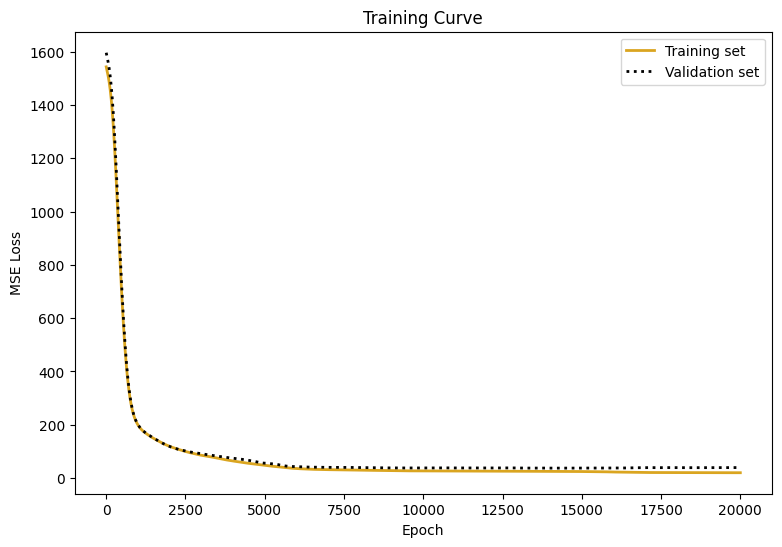

In [133]:
plt.figure(figsize = (9,6))
plt.plot(loss_history[:,0], 'goldenrod', linewidth=2)
plt.plot(loss_history[:,1], 'k:', linewidth=2)    
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.title("Training Curve")
plt.legend(['Training set', 'Validation set'], loc='upper right')
plt.show()

### Prediction with the neural network

In [134]:
model.eval()

with torch.no_grad():
    y_test_pred = model(X_test_tensor)

# Convert predictions back to NumPy
y_test_pred_np = y_test_pred.numpy()

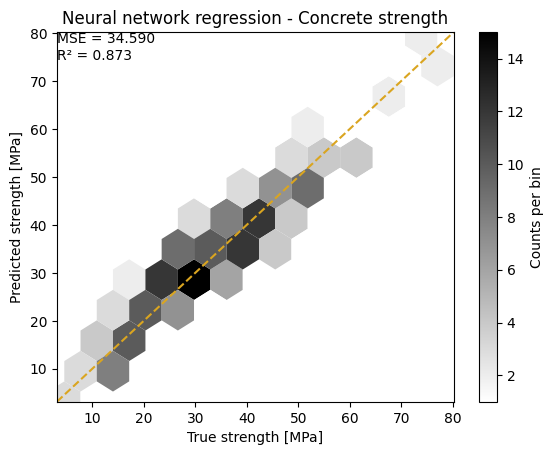

In [135]:
parity_plot(
    y_test.flatten(),
    y_test_pred_np.flatten(),
    title="Neural network regression - Concrete strength"
)

### Predictive performance is measured through:

- Mean Squared Error (MSE)
- Coefficient of determination $R^2$

---

## Remarks: Linear regression vs neural network

### Linear regression

A multivariate linear regression assumes a linear relationship between the inputs and the output:

$y = w_1 x_1 + w_2 x_2 + \dots + w_n x_n + b$

---

### Neural network

A neural network introduces hidden layers and nonlinear activation functions, allowing to learn:

- nonlinear relationships
- interactions between variables
- more complex patterns in the data

---

### Important observations:

1. Neural networks generally train much better when inputs are standardized.
2. By increasing the number of parameters, a neural network can represent more complex functions than linear regression. However, too many parameters may cause overfitting and require more data for effective training.
3. Neural networks are universal function approximators; even a small network with one hidden layer can approximate highly nonlinear functions.

---

### Exercise

Try a deeper and larger network, for instance:

            self.network = nn.Sequential(
                nn.Linear(input_size, 32),
                nn.ReLU(),
                nn.Linear(32, 16),
                nn.ReLU(),
                nn.Linear(16, 1)
            )

and compare the results.

---

Other possible options: 
1. Try different activation functions (sigmoid, Tanh, LeakyReLU...)
2. Compare performance with linear regression
3. Explore the effect of learning rate, number of epochs, batch training, ...
4. Add weigth regularization